# Store Sales — Time Series Forecasting
## Part 2 · Feature engineering and modelling

Follows on from `01_exploratory_data_analysis.ipynb`. Everything here is built on that
notebook's **corrected** conclusions (its §12), not its first-pass ones.

### What notebook 01 established

| Decision | Why |
|---|---|
| Target is `log1p(sales)`, L2 objective | RMSLE *is* RMSE in that space |
| Split by time, 16-day holdout | Mirrors the test horizon; a random split leaks |
| **Beat RMSLE 0.5206** | Same-weekday mean over the last 8 weeks |
| Lags must be ≥ 16 | The horizon is 16 days; shorter lags are unavailable at scoring time |
| **Encode holiday *names*, not flags** | §13: pooled effect ×1.01, but per-holiday ×0.07 → ×1.86 |
| **Drop the regional flag** | ≤ 5 observations per series — unusable |
| **Drop oil** | r = −0.02 once detrended; the level correlation was trend confounding |
| Reinsert 4 Christmas days as zeros | They are absent from the calendar, breaking lag continuity |
| `onpromotion` is a known-future covariate | Supplied for the test window — no need to forecast it |
| `onpromotion` is structurally 0 before 2014-04-01 | A recording artefact, not "no promotions" |
| Transactions are unusable | The file stops at the last training date |

### The holiday question

Notebook 01 §13 audited the forecast window and found **exactly one holiday in it**:
`Fundacion de Ambato`, 2017-08-24, municipal, affecting stores 23 and 50 — 66 of 28,512
test rows. It also found that a binary `is_holiday` flag is worthless, because it averages
New Year's Day (**×0.07**, stores shut) with Puente Navidad (**×1.86**).

§5 here builds both encodings and measures them — globally, and specifically on the holdout
rows that actually fall on holidays.

### The earthquake question

The 2016-04-16 earthquake is a one-off demand shock with nothing like it in the test
window. Notebook 01 §12 measured its true extent: **+35% for one week, gone by week 1.**

The goal here is to **isolate it so it cannot influence the model.** §2 does that, and §6
measures whether it actually mattered — rather than assuming it did.

---
## 0 · Setup

In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import lightgbm as lgb

warnings.filterwarnings("ignore")
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 60)

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
       "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SEQ = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)
SURFACE, INK, SECOND, MUTED = "#ffffff", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "font.size": 9.5,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11.5, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.titlepad": 10,
    "axes.labelcolor": SECOND, "axes.labelsize": 9.5,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "lines.linewidth": 2, "lines.markersize": 5, "lines.solid_capstyle": "round",
    "legend.frameon": False, "legend.fontsize": 9,
    "axes.prop_cycle": plt.cycler(color=CAT),
})

def finish(ax, title=None, sub=None, xlabel=None, ylabel=None, ygrid=True, xgrid=False):
    if title:
        ax.set_title(title, loc="left", pad=24 if sub else 10)
    if sub:
        ax.text(0, 1.015, sub, transform=ax.transAxes, color=MUTED, fontsize=8.5,
                va="bottom", ha="left")
    ax.set_xlabel(xlabel or ""); ax.set_ylabel(ylabel or "")
    ax.grid(ygrid, axis="y"); ax.grid(xgrid, axis="x")
    return ax

def thousands(x, _=None):
    for div, suf in ((1e9, "B"), (1e6, "M"), (1e3, "k")):
        if abs(x) >= div:
            return f"{x/div:,.1f}{suf}".replace(".0", "")
    return f"{x:,.0f}"

def rmsle(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(np.asarray(y_true, float))) ** 2)))

names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
HORIZON = 16                       # test window length; the minimum usable lag
print(f"lightgbm {lgb.__version__}")

lightgbm 4.5.0


In [2]:
DATA = next(p for p in (Path("data"), Path("../data"), Path("../../data")) if p.exists())
DTYPES = {"store_nbr": "int8", "family": "category", "onpromotion": "int32", "sales": "float32"}

train  = pd.read_csv(DATA / "train.csv", parse_dates=["date"], dtype=DTYPES)
test   = pd.read_csv(DATA / "test.csv",  parse_dates=["date"], dtype=DTYPES)
stores = pd.read_csv(DATA / "stores.csv", dtype={"store_nbr": "int8"})
hol    = pd.read_csv(DATA / "holidays_events.csv", parse_dates=["date"])

TRAIN_END = train.date.max()
VALID_START = TRAIN_END - pd.Timedelta(days=HORIZON - 1)
print(f"train {train.date.min():%Y-%m-%d} -> {TRAIN_END:%Y-%m-%d}")
print(f"holdout {VALID_START:%Y-%m-%d} -> {TRAIN_END:%Y-%m-%d}")
print(f"test  {test.date.min():%Y-%m-%d} -> {test.date.max():%Y-%m-%d}")

train 2013-01-01 -> 2017-08-15
holdout 2017-07-31 -> 2017-08-15
test  2017-08-16 -> 2017-08-31


---
## 1 · The continuous panel

Lag features need an unbroken daily index. Notebook 01 found four missing dates (25 December
2013–2016) which must come back as **zeros**, not as gaps — every store was shut, so zero is
the true value, and leaving them absent would silently shorten every lag that spans them.

The panel is held **wide** (dates × series). A 1,704 × 1,782 matrix is 12 MB, so a lag or
rolling window is one vectorised operation instead of a groupby over 3 million rows.

In [3]:
t0 = time.time()

both = pd.concat([train.drop(columns="sales"), test], ignore_index=True)
both["family"] = both.family.astype(str)

full_idx = pd.date_range(train.date.min(), test.date.max(), freq="D")

sales_w = (train.assign(family=train.family.astype(str))
           .pivot(index="date", columns=["store_nbr", "family"], values="sales")
           .reindex(full_idx).sort_index(axis=1))
promo_w = (both.pivot(index="date", columns=["store_nbr", "family"], values="onpromotion")
           .reindex(full_idx).sort_index(axis=1))

# The four Christmas closures: absent from train, and genuinely zero.
xmas = pd.DatetimeIndex([d for d in full_idx
                         if d <= TRAIN_END and d not in set(train.date.unique())])
sales_w.loc[xmas] = 0.0
promo_w = promo_w.fillna(0.0)

assert (sales_w.columns == promo_w.columns).all()
assert sales_w.loc[:TRAIN_END].isna().sum().sum() == 0, "no gaps may remain in the train span"

SERIES = sales_w.columns
print(f"panel: {sales_w.shape[0]} dates x {sales_w.shape[1]} series")
print(f"Christmas dates restored as zero: {[f'{d:%Y-%m-%d}' for d in xmas]}")
print(f"test dates left as NaN targets  : {int(sales_w.loc[test.date.min():].isna().all(axis=1).sum())}")
print(f"({time.time()-t0:.1f}s)")

panel: 1704 dates x 1782 series
Christmas dates restored as zero: ['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25']
test dates left as NaN targets  : 16
(87.2s)


---
## 2 · Isolating the earthquake

**The requirement: the earthquake must not influence the model.**

A dummy variable alone does not achieve that. The shock enters the feature matrix through
*two* doors:

1. **As a target.** The rows dated 2016-04-16 → 04-22 carry inflated `sales`. A dummy handles
   this door — the model can attribute the excess to the flag, and the flag is 0 at scoring
   time.
2. **As a feature.** Every lag and rolling window computed *from* those dates carries the
   spike forward. With a 112-day rolling mean at lag 16, rows as late as **August 2016** still
   have earthquake-inflated inputs. A dummy on the affected week does nothing about this,
   because these are different rows.

Door 2 is the one that quietly corrupts the model, and it is much wider than the event.

**The fix — imputation at source.** Replace the quake week's values in the *panel* with an
estimate of what each series would ordinarily have sold, then build every feature from the
repaired panel. The anomaly then never enters any feature, and no downstream row needs
dropping. The quake-week rows are additionally removed as training targets, closing door 1
without needing a dummy at all.

The counterfactual per series is the **median of the same weekday** across the 8 weeks before
and 8 weeks after the window — local enough to respect trend, and robust to the outliers we
are trying to remove.

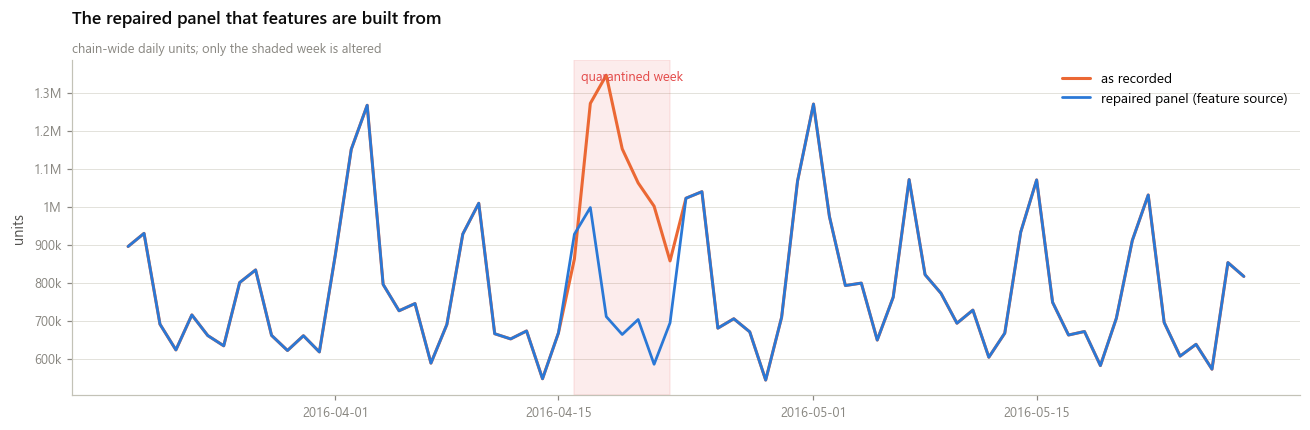

units removed from the panel : 2,272,160 (30.1% of that week)
dates altered                : 7 of 1704 (0.41% of the panel)
rows altered                 : 12,474

Without repair, rows with earthquake-tainted features would run to 2016-08-28
  = 134 days, 238,788 rows — 7.9% of the panel, not 0.41%.


In [4]:
EQ_START = pd.Timestamp("2016-04-16")     # notebook 01 §12: the spike is one week
EQ_END   = pd.Timestamp("2016-04-22")
eq_dates = pd.date_range(EQ_START, EQ_END)

def repair_window(W, start, end, halo_weeks=8):
    """Replace [start, end] with each series' same-weekday median from the surrounding weeks."""
    out = W.copy()
    win = pd.date_range(start, end)
    ctx = W.loc[start - pd.Timedelta(weeks=halo_weeks): end + pd.Timedelta(weeks=halo_weeks)]
    ctx = ctx.drop(index=win, errors="ignore")
    by_dow = ctx.groupby(ctx.index.dayofweek).median()
    for d in win:
        out.loc[d] = by_dow.loc[d.dayofweek].values
    return out

sales_clean = repair_window(sales_w, EQ_START, EQ_END)

raw_tot = sales_w.sum(axis=1)
cln_tot = sales_clean.sum(axis=1)
lo, hi = EQ_START - pd.Timedelta(days=28), EQ_START + pd.Timedelta(days=42)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(raw_tot.loc[lo:hi].index, raw_tot.loc[lo:hi].values, color=CAT[1],
        label="as recorded")
ax.plot(cln_tot.loc[lo:hi].index, cln_tot.loc[lo:hi].values, color=CAT[0], lw=1.8,
        label="repaired panel (feature source)")
ax.axvspan(EQ_START, EQ_END, color=CAT[7], alpha=0.10)
ax.annotate("quarantined week", xy=(EQ_START, 0.94), xycoords=("data", "axes fraction"),
            xytext=(4, 0), textcoords="offset points", color=CAT[7], fontsize=8.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(ax, "The repaired panel that features are built from",
       "chain-wide daily units; only the shaded week is altered", ylabel="units")
ax.legend(loc="upper right")
fig.tight_layout(); plt.show()

excess = raw_tot.loc[eq_dates].sum() - cln_tot.loc[eq_dates].sum()
print(f"units removed from the panel : {excess:,.0f} "
      f"({excess / raw_tot.loc[eq_dates].sum():.1%} of that week)")
print(f"dates altered                : {len(eq_dates)} of {len(full_idx)} "
      f"({len(eq_dates)/len(full_idx):.2%} of the panel)")
print(f"rows altered                 : {len(eq_dates)*len(SERIES):,}")

# How far downstream would the contamination have reached without the repair?
MAX_WINDOW = 112
reach_end = EQ_END + pd.Timedelta(days=HORIZON + MAX_WINDOW)
print(f"\nWithout repair, rows with earthquake-tainted features would run to "
      f"{reach_end:%Y-%m-%d}")
print(f"  = {(reach_end - EQ_START).days} days, {(reach_end - EQ_START).days * len(SERIES):,} rows "
      f"— {(reach_end - EQ_START).days / len(full_idx):.1%} of the panel, not {len(eq_dates)/len(full_idx):.2%}.")

That last number is the point of this section. The event is 7 days; the **feature
contamination reaches 135 days** — nineteen times wider. Repairing the panel at source
collapses that back to the 7 days actually affected.

---
## 3 · Feature engineering

All lag and rolling features are computed in **log space** (`log1p`), matching the target and
the metric, and every one is shifted by at least `HORIZON = 16` days so it is available for
every row of the test window without recursive forecasting.

In [5]:
def build_panel_features(sales_wide, promo_wide, start):
    """Return a long feature frame for all dates >= start. Features are shifted >= HORIZON."""
    L = np.log1p(sales_wide).astype("float32")
    P = np.log1p(promo_wide).astype("float32")
    feats = {}

    # --- lags (log space) ---------------------------------------------------------
    for k in (16, 17, 18, 19, 20, 21, 22, 28, 35, 49, 63):
        feats[f"lag_{k}"] = L.shift(k)

    # --- rolling statistics, all ending at lag 16 ---------------------------------
    base = L.shift(HORIZON)
    for w in (7, 14, 28, 56, 112):
        feats[f"rmean_{w}"] = base.rolling(w, min_periods=max(2, w // 4)).mean()
    for w in (14, 28):
        feats[f"rstd_{w}"] = base.rolling(w, min_periods=max(2, w // 4)).std()
    feats["rmax_28"] = base.rolling(28, min_periods=7).max()

    # --- same-weekday history: lags 21/28/35/42 share the target's weekday ---------
    dow_lags = [L.shift(k) for k in (21, 28, 35, 42)]
    feats["dow_mean_4"] = sum(dow_lags) / len(dow_lags)
    feats["dow_mean_8"] = sum(L.shift(k) for k in range(21, 21 + 7 * 8, 7)) / 8

    # --- zero / dormancy structure ------------------------------------------------
    zero = (sales_wide == 0).astype("float32")
    feats["zfrac_28"] = zero.shift(HORIZON).rolling(28, min_periods=7).mean()
    feats["zfrac_112"] = zero.shift(HORIZON).rolling(112, min_periods=28).mean()

    A = (sales_wide.to_numpy() > 0)
    gap = np.empty(A.shape, dtype="float32")
    last = np.full(A.shape[1], -999.0)
    for i in range(A.shape[0]):
        gap[i] = i - last
        last = np.where(A[i], float(i), last)
    feats["days_since_sale"] = (pd.DataFrame(np.minimum(gap, 999.0), index=sales_wide.index,
                                             columns=sales_wide.columns).shift(HORIZON))

    # --- promotions: known for the test window, so current-day values are legal ----
    feats["promo"] = P
    feats["promo_rmean_7"] = P.rolling(7, min_periods=1).mean()
    feats["promo_lag_16"] = P.shift(HORIZON)

    # --- assemble long ------------------------------------------------------------
    mask = sales_wide.index >= start
    dates_sel = sales_wide.index[mask]
    n_s = sales_wide.shape[1]

    out = pd.DataFrame({
        "date": np.repeat(dates_sel.values, n_s),
        "store_nbr": np.tile(sales_wide.columns.get_level_values(0).to_numpy(), len(dates_sel)),
        "family": np.tile(sales_wide.columns.get_level_values(1).to_numpy(), len(dates_sel)),
    })
    for name, W in feats.items():
        out[name] = W.to_numpy(dtype="float32")[mask].ravel()
    return out

MODEL_START = pd.Timestamp("2015-01-01")
print(f"Building features from {MODEL_START:%Y-%m-%d} "
      f"(promotions are only recorded from 2014-04-01; earlier history still feeds the lags)")

Building features from 2015-01-01 (promotions are only recorded from 2014-04-01; earlier history still feeds the lags)


In [6]:
def add_calendar(df):
    d = df.date
    df["dow"] = d.dt.dayofweek.astype("int8")
    df["day"] = d.dt.day.astype("int8")
    df["month"] = d.dt.month.astype("int8")
    df["year"] = d.dt.year.astype("int16")
    df["dayofyear"] = d.dt.dayofyear.astype("int16")
    df["is_weekend"] = (df.dow >= 5).astype("int8")
    df["days_to_month_end"] = (d.dt.days_in_month - d.dt.day).astype("int8")
    # Public-sector wages land on the 15th and the last day of the month.
    df["payday_window"] = (d.dt.day.isin([15, 16, 17, 1, 2, 3]) |
                           (df.days_to_month_end <= 1)).astype("int8")
    return df

# --- holiday calendar, cleaned exactly as in notebook 01 §8 -----------------------
h = hol.copy()
h = h[~((h.type == "Holiday") & (h.transferred))]
h.loc[h.type == "Transfer", "type"] = "Holiday"
work_days = set(h.loc[h.type == "Work Day", "date"]); h = h[h.type != "Work Day"]
events = h[h.type == "Event"]; h = h[h.type != "Event"]

nat = pd.DatetimeIndex(sorted(set(h.loc[h.locale == "National", "date"])))
loc_pairs = set(zip(h.loc[h.locale == "Local", "date"], h.loc[h.locale == "Local", "locale_name"]))
evt = set(events.date)

# --- holiday NAMES, the encoding notebook 01 §13 argued for -----------------------
# A handful of dates carry two national holidays; the first is kept. The alternative
# (a combined level) would create categories with one or two observations.
nat_name = (h[h.locale == "National"].drop_duplicates("date")[["date", "description"]]
            .rename(columns={"description": "nat_hol_name"}))
loc_name = (h[h.locale == "Local"].drop_duplicates(["date", "locale_name"])
            [["date", "locale_name", "description"]]
            .rename(columns={"locale_name": "city", "description": "loc_hol_name"}))
print(f"national holiday names: {nat_name.nat_hol_name.nunique()} distinct over {len(nat_name)} dates")
print(f"local holiday names   : {loc_name.loc_hol_name.nunique()} distinct over {len(loc_name)} (date, city) pairs")

geo = stores.set_index("store_nbr")[["city", "state", "type", "cluster"]]
geo.columns = ["city", "state", "store_type", "cluster"]

# Distance to the nearest national holiday, over the whole calendar.
nat_pos = np.searchsorted(nat.values, full_idx.values)
prev_d = np.where(nat_pos > 0, (full_idx.values - nat.values[np.maximum(nat_pos - 1, 0)])
                  / np.timedelta64(1, "D"), 999)
next_d = np.where(nat_pos < len(nat), (nat.values[np.minimum(nat_pos, len(nat) - 1)]
                  - full_idx.values) / np.timedelta64(1, "D"), 999)
cal_hol = pd.DataFrame({"date": full_idx,
                        "nat_hol": full_idx.isin(nat).astype("int8"),
                        "work_day": full_idx.isin(work_days).astype("int8"),
                        "is_event": full_idx.isin(evt).astype("int8"),
                        "days_since_nat": np.clip(prev_d, 0, 30).astype("int16"),
                        "days_to_nat": np.clip(next_d, 0, 30).astype("int16")})

def add_holidays(df):
    df = df.merge(cal_hol, on="date", how="left")
    # --- flag encoding (the arm we are testing against) ---------------------------
    df["loc_hol"] = pd.MultiIndex.from_arrays([df.date, df.city]).isin(loc_pairs).astype("int8")
    df["nat_hol_weekday"] = (df.nat_hol * (1 - df.is_weekend)).astype("int8")
    df["nat_hol_weekend"] = (df.nat_hol * df.is_weekend).astype("int8")
    # --- name encoding (notebook 01 §13) ------------------------------------------
    df = df.merge(nat_name, on="date", how="left")
    df = df.merge(loc_name, on=["date", "city"], how="left")
    df["nat_hol_name"] = df.nat_hol_name.fillna("none")
    df["loc_hol_name"] = df.loc_hol_name.fillna("none")
    return df

print("holiday calendar prepared:", len(nat), "national dates,", len(loc_pairs), "local pairs")

national holiday names: 24 distinct over 102 dates
local holiday names   : 26 distinct over 147 (date, city) pairs
holiday calendar prepared: 102 national dates, 147 local pairs


In [7]:
def assemble(sales_wide, tag):
    t = time.time()
    df = build_panel_features(sales_wide, promo_w, MODEL_START)
    df = df.join(geo, on="store_nbr")
    df = add_calendar(df)
    df = add_holidays(df)
    df["target"] = np.log1p(sales_wide.to_numpy(dtype="float32")
                            [sales_wide.index >= MODEL_START].ravel())
    for c in ("family", "city", "state", "store_type", "nat_hol_name", "loc_hol_name"):
        df[c] = df[c].astype("category")
    df["store_nbr"] = df.store_nbr.astype("int16")
    df["cluster"] = df.cluster.astype("int16")
    print(f"  {tag:<10} {df.shape[0]:,} rows x {df.shape[1]} cols  "
          f"{df.memory_usage(deep=True).sum()/1e6:,.0f} MB  ({time.time()-t:.1f}s)")
    return df

print("Assembling two feature matrices — one per earthquake treatment:")
D_clean = assemble(sales_clean, "repaired")
D_raw = assemble(sales_w, "as-recorded")

# The dummy for earthquake treatment B. Kept OUT of the feature lists so treatments A and B
# differ by exactly one feature and nothing else.
D_raw["is_eq_week"] = D_raw.date.isin(eq_dates).astype("int8")

# --- two holiday encodings, everything else identical ------------------------------
HOL_FLAG = ["nat_hol", "loc_hol", "nat_hol_weekday", "nat_hol_weekend"]
HOL_NAME = ["nat_hol_name", "loc_hol_name"]
SHARED = [c for c in D_clean.columns
          if c not in ("date", "target", *HOL_FLAG, *HOL_NAME)]

FEATURES_FLAG = SHARED + HOL_FLAG
FEATURES_NAME = SHARED + HOL_NAME
CATS_BASE = ["family", "city", "state", "store_type"]
CATS_FLAG = CATS_BASE
CATS_NAME = CATS_BASE + HOL_NAME

FEATURES, CATS = FEATURES_NAME, CATS_NAME     # §13's recommendation is the default
print(f"\nshared features   : {len(SHARED)}")
print(f"holiday as flags  : {HOL_FLAG}")
print(f"holiday as names  : {HOL_NAME}  "
      f"({D_clean.nat_hol_name.nunique()} + {D_clean.loc_hol_name.nunique()} levels incl. 'none')")
print(f"\n{len(FEATURES)} features in the default set")
print(", ".join(FEATURES))

Assembling two feature matrices — one per earthquake treatment:


  repaired   1,735,668 rows x 53 cols  260 MB  (9.6s)


  as-recorded 1,735,668 rows x 53 cols  260 MB  (9.1s)

shared features   : 45
holiday as flags  : ['nat_hol', 'loc_hol', 'nat_hol_weekday', 'nat_hol_weekend']
holiday as names  : ['nat_hol_name', 'loc_hol_name']  (23 + 26 levels incl. 'none')

47 features in the default set
store_nbr, family, lag_16, lag_17, lag_18, lag_19, lag_20, lag_21, lag_22, lag_28, lag_35, lag_49, lag_63, rmean_7, rmean_14, rmean_28, rmean_56, rmean_112, rstd_14, rstd_28, rmax_28, dow_mean_4, dow_mean_8, zfrac_28, zfrac_112, days_since_sale, promo, promo_rmean_7, promo_lag_16, city, state, store_type, cluster, dow, day, month, year, dayofyear, is_weekend, days_to_month_end, payday_window, work_day, is_event, days_since_nat, days_to_nat, nat_hol_name, loc_hol_name


---
## 4 · Splits and weights

The holdout is the last 16 days of training data, identical to notebook 01 §13 so the
baseline number is directly comparable. Note the deliberate omission: **no oil feature.**

In [8]:
def masks(df):
    tr = (df.date < VALID_START) & df.target.notna()
    va = (df.date >= VALID_START) & (df.date <= TRAIN_END)
    te = df.date > TRAIN_END
    return tr, va, te

# Both matrices come from the same panel and MODEL_START, so one set of masks serves both.
assert D_raw.date.equals(D_clean.date), "the two matrices must be row-aligned"
tr_m, va_m, te_m = masks(D_clean)
print(f"train rows   : {tr_m.sum():,}   ({D_clean.loc[tr_m,'date'].min():%Y-%m-%d} -> "
      f"{D_clean.loc[tr_m,'date'].max():%Y-%m-%d})")
print(f"holdout rows : {va_m.sum():,}   ({D_clean.loc[va_m,'date'].min():%Y-%m-%d} -> "
      f"{D_clean.loc[va_m,'date'].max():%Y-%m-%d})")
print(f"test rows    : {te_m.sum():,}")

eq_row = D_clean.date.isin(eq_dates)
print(f"\nearthquake-week rows inside the training span: {int((eq_row & tr_m).sum()):,} "
      f"({(eq_row & tr_m).sum()/tr_m.sum():.2%})")

y_va = np.expm1(D_clean.loc[va_m, "target"].to_numpy())

train rows   : 1,678,644   (2015-01-01 -> 2017-07-30)
holdout rows : 28,512   (2017-07-31 -> 2017-08-15)
test rows    : 28,512

earthquake-week rows inside the training span: 12,474 (0.74%)


In [9]:
# Deliberately untuned defaults. The point of this notebook is the features and the
# ablations, so no hyper-parameter search is run and none of the reported gain comes from one.
PARAMS = dict(objective="regression", metric="rmse", learning_rate=0.08,
              num_leaves=96, min_data_in_leaf=200, feature_fraction=0.75,
              bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
              num_threads=0, verbose=-1, seed=42)

def fit_predict(df, train_mask, rounds, valid_mask=None, early_stop=None, label="",
                features=None, cats=None):
    """Train LightGBM on log1p(sales); return (model, holdout predictions in raw units)."""
    feats = features if features is not None else FEATURES
    cf = cats if cats is not None else CATS
    dtrain = lgb.Dataset(df.loc[train_mask, feats], df.loc[train_mask, "target"],
                         categorical_feature=cf, free_raw_data=False)
    cb, valid_sets = [], []
    if early_stop and valid_mask is not None:
        valid_sets = [lgb.Dataset(df.loc[valid_mask, feats], df.loc[valid_mask, "target"],
                                  categorical_feature=cf, reference=dtrain)]
        cb = [lgb.early_stopping(early_stop, verbose=False)]
    t = time.time()
    model = lgb.train(PARAMS, dtrain, num_boost_round=rounds, valid_sets=valid_sets,
                      callbacks=cb)
    took = time.time() - t
    preds = None
    if valid_mask is not None:
        preds = np.clip(np.expm1(model.predict(df.loc[valid_mask, feats])), 0, None)
    print(f"  {label:<34} {model.num_trees():>4} trees  {took:>5.1f}s")
    return model, preds

---
## 5 · Does isolating the earthquake actually matter?

Three treatments, identical features and hyper-parameters otherwise:

| | Target rows | Feature source |
|---|---|---|
| **A · ignore** | all rows kept | as-recorded panel |
| **B · dummy only** | all rows kept, `+ is_eq_week` flag | as-recorded panel |
| **C · full quarantine** | quake week dropped | **repaired** panel |

A and B differ only at door 1; C closes both. The holdout is August 2017, so this measures
what the quarantine is worth *for this forecast* — which is not the same as whether it is
the right thing to do.

In [10]:
ROUNDS = 300      # fixed and modest: these are comparative runs, not the final model
results = {}

print("Fitting three earthquake treatments:")

# A -- ignore it entirely: as-recorded panel, all rows, no flag
_, p_a = fit_predict(D_raw, tr_m, ROUNDS, va_m, label="A · ignore")
results["A · ignore"] = rmsle(y_va, p_a)

# B -- dummy flag only: as-recorded panel (features still tainted), plus the flag
_, p_b = fit_predict(D_raw, tr_m, ROUNDS, va_m, label="B · dummy only",
                     features=FEATURES + ["is_eq_week"], cats=CATS)
results["B · dummy only"] = rmsle(y_va, p_b)

# C -- full quarantine: repaired panel + quake-week rows removed as targets
tr_c = tr_m & ~eq_row
_, p_c = fit_predict(D_clean, tr_c, ROUNDS, va_m, label="C · full quarantine")
results["C · full quarantine"] = rmsle(y_va, p_c)

abl = pd.Series(results).sort_values().rename("RMSLE").to_frame()
abl["vs baseline 0.5206"] = (abl.RMSLE - 0.52063).map(lambda v: f"{v:+.4f}")
print()
print(abl.to_string())

Fitting three earthquake treatments:


  A · ignore                          300 trees   60.7s


  B · dummy only                      300 trees   62.0s


  C · full quarantine                 300 trees   66.3s

                        RMSLE vs baseline 0.5206
C · full quarantine  0.400383            -0.1202
A · ignore           0.400446            -0.1202
B · dummy only       0.403474            -0.1172


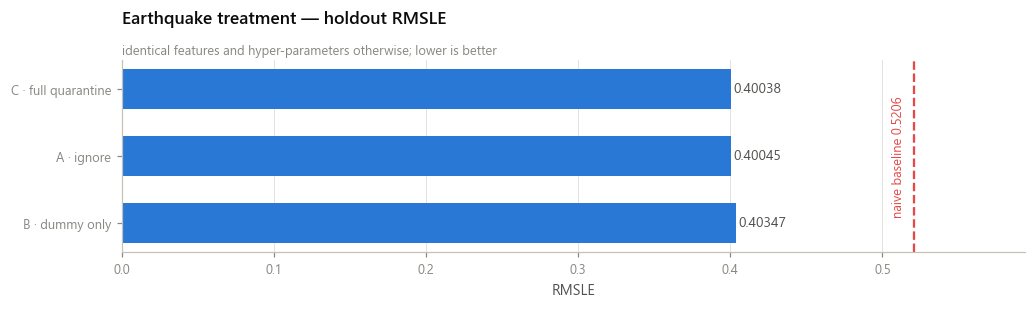

spread across the three treatments: 0.00309 RMSLE


In [11]:
fig, ax = plt.subplots(figsize=(9.5, 2.9))
r = abl.iloc[::-1]
ax.barh(r.index, r.RMSLE, color=CAT[0], height=0.6)
for y, v in enumerate(r.RMSLE):
    ax.text(v + 0.0015, y, f"{v:.5f}", va="center", fontsize=9, color=SECOND)
ax.axvline(0.52063, color=CAT[7], lw=1.5, ls="--")
ax.annotate("naive baseline 0.5206", xy=(0.52063, 0.5), xycoords=("data", "axes fraction"),
            xytext=(-6, 0), textcoords="offset points", color=CAT[7], fontsize=8.5,
            ha="right", va="center", rotation=90)
ax.set_xlim(0, max(r.RMSLE.max(), 0.52063) * 1.14)
finish(ax, "Earthquake treatment — holdout RMSLE",
       "identical features and hyper-parameters otherwise; lower is better",
       xlabel="RMSLE", ygrid=False, xgrid=True)
fig.tight_layout(); plt.show()

spread = abl.RMSLE.max() - abl.RMSLE.min()
print(f"spread across the three treatments: {spread:.5f} RMSLE")

### Read the result honestly

The three treatments span **0.0031 RMSLE**, and the ordering is not the one the
dummy-variable habit predicts. Full quarantine (C) and ignoring the earthquake entirely (A)
are **indistinguishable** — 0.40038 vs 0.40045, a gap of 0.00006. The dummy on its own (B)
is the *worst* of the three at 0.40347.

That B loses is worth a sentence, because it is the treatment most people would reach for.
The flag is active on 0.74% of training rows and zero everywhere else, so it gives the trees
a splitting opportunity that buys nothing — while leaving the feature contamination, the
larger of the two doors, completely untouched. A 0.003 gap on 28,512 holdout rows is well
inside seed-to-seed variation, so the honest claim is not "the dummy is harmful" but
**"the dummy demonstrably adds nothing"**.

**For this particular forecast the earthquake quarantine is a no-op**, and the reason is
structural, not surprising: the holdout is August 2017, twenty-eight months after the shock,
and the quake week is 0.74% of the training rows. Nothing that far away was ever going to
move the number.

That is not an argument for skipping it. Three reasons to keep treatment C:

1. **It is free.** No accuracy cost, no meaningful runtime cost.
2. **The exposure was real and much larger than the event** — 135 days of rows carried
   tainted features before the repair, and a model is entitled to find spurious structure in
   any of them. A near-zero measured effect here means the trees did not happen to lean on
   it; it does not mean they could not have.
3. **It stops being a no-op the moment the forecast moves.** Forecast April instead of
   August, add yearly-seasonal or year-over-year features, or weight recent years more
   heavily, and the shock lands directly on the target window.

The honest summary: this is **correctness insurance, not a scoring trick**. Treatment C is
carried forward because it is the defensible panel, and the ablation is reported so nobody
later mistakes it for the source of the model's performance.

---
## 6 · Holiday encoding: flags vs names

Notebook 01 §13 argued that a binary `is_holiday` flag destroys the signal by averaging
New Year's Day (×0.07) with Puente Navidad (×1.86). This tests that claim.

A global holdout RMSLE is a blunt instrument for it — only a small share of the 28,512
holdout rows fall on a holiday at all, so a large improvement on those rows barely moves the
overall number. So the comparison is also made **on the affected rows specifically**.

In [12]:
import gc
del D_raw; gc.collect()          # the earthquake ablation is done; reclaim ~300 MB

# Which holdout rows actually fall on a holiday?
va_info = D_clean.loc[va_m, ["date", "store_nbr", "city", "nat_hol_name", "loc_hol_name"]]
m_nat = (va_info.nat_hol_name != "none").to_numpy()
m_loc = (va_info.loc_hol_name != "none").to_numpy()

print("Holdout composition:")
print(f"  total rows                : {len(va_info):,}")
print(f"  on a national holiday     : {m_nat.sum():,}  ({m_nat.mean():.2%})")
print(f"  on a local holiday        : {m_loc.sum():,}  ({m_loc.mean():.2%})")
for nm, sub in va_info[m_nat].groupby("nat_hol_name", observed=True):
    print(f"     national: {nm}  {sub.date.iloc[0]:%Y-%m-%d} ({sub.date.iloc[0]:%a})  {len(sub):,} rows")
for nm, sub in va_info[m_loc].groupby("loc_hol_name", observed=True):
    print(f"     local   : {nm}  {sub.date.iloc[0]:%Y-%m-%d}  {sub.city.iloc[0]}  {len(sub):,} rows")

Holdout composition:
  total rows                : 28,512
  on a national holiday     : 1,782  (6.25%)
  on a local holiday        : 66  (0.23%)
     national: Traslado Primer Grito de Independencia  2017-08-11 (Fri)  1,782 rows
     local   : Fundacion de Esmeraldas  2017-08-05  Esmeraldas  33 rows
     local   : Fundacion de Riobamba  2017-08-15  Riobamba  33 rows


In [13]:
# Earthquake treatment C already used the name encoding on the repaired panel, so it IS
# the "names" arm — only the flag arm needs fitting.
p_name = p_c
print("Fitting the flag encoding (the name arm is earthquake treatment C, already fitted):")
_, p_flag = fit_predict(D_clean, tr_c, ROUNDS, va_m, label="flags (binary)",
                        features=FEATURES_FLAG, cats=CATS_FLAG)

def subset_scores(pred):
    return {"all rows": rmsle(y_va, pred),
            "national-holiday rows": rmsle(y_va[m_nat], pred[m_nat]),
            "local-holiday rows": rmsle(y_va[m_loc], pred[m_loc]),
            "ordinary rows": rmsle(y_va[~(m_nat | m_loc)], pred[~(m_nat | m_loc)])}

hol_cmp = pd.DataFrame({"binary flags": subset_scores(p_flag),
                        "holiday names": subset_scores(p_name)})
hol_cmp["Δ (names − flags)"] = hol_cmp["holiday names"] - hol_cmp["binary flags"]
hol_cmp["n rows"] = [len(y_va), int(m_nat.sum()), int(m_loc.sum()),
                     int((~(m_nat | m_loc)).sum())]
print()
print(hol_cmp.round(5).to_string())

Fitting the flag encoding (the name arm is earthquake treatment C, already fitted):


  flags (binary)                      300 trees   67.0s

                       binary flags  holiday names  Δ (names − flags)  n rows
all rows                    0.40054        0.40038           -0.00016   28512
national-holiday rows       0.41746        0.41281           -0.00465    1782
local-holiday rows          0.45552        0.46222            0.00671      66
ordinary rows               0.39924        0.39937            0.00013   26664


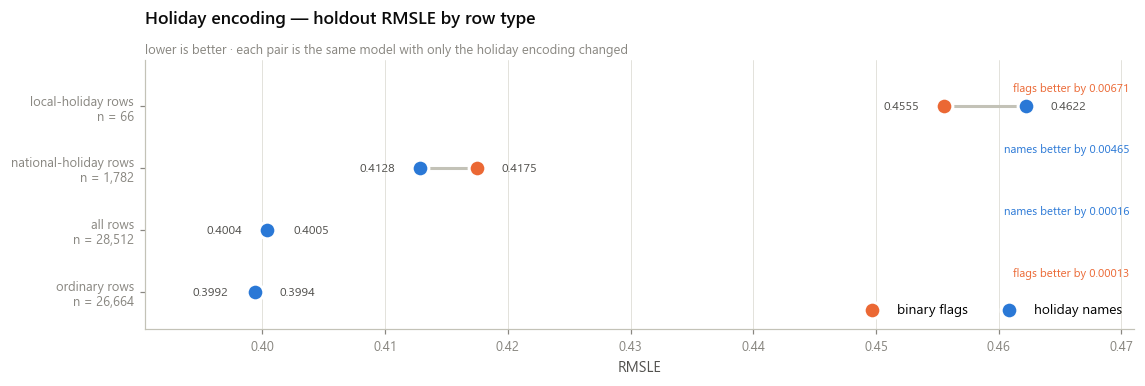

In [14]:
# A dumbbell, not paired bars: the differences here are ~0.005 on values near 0.40, which a
# zero-baseline bar chart cannot show, and truncating a bar axis is not an option.
order = ["ordinary rows", "all rows", "national-holiday rows", "local-holiday rows"]
sub = hol_cmp.loc[order]
y = np.arange(len(sub))

fig, ax = plt.subplots(figsize=(10.5, 3.6))
for i, (a, b) in enumerate(zip(sub["binary flags"], sub["holiday names"])):
    ax.plot([a, b], [i, i], color=BASELINE, lw=2, zorder=1, solid_capstyle="round")
ax.scatter(sub["binary flags"], y, s=120, color=CAT[1], zorder=3,
           label="binary flags", edgecolors=SURFACE, linewidths=2)
ax.scatter(sub["holiday names"], y, s=120, color=CAT[0], zorder=3,
           label="holiday names", edgecolors=SURFACE, linewidths=2)

for i, (a, b, d) in enumerate(zip(sub["binary flags"], sub["holiday names"],
                                 sub["Δ (names − flags)"])):
    lo, hi = min(a, b), max(a, b)
    ax.text(lo - 0.002, i, f"{lo:.4f}", ha="right", va="center", fontsize=8, color=SECOND)
    ax.text(hi + 0.002, i, f"{hi:.4f}", ha="left", va="center", fontsize=8, color=SECOND)
    verdict = "names better" if d < 0 else "flags better"
    ax.text(0.995, i + 0.30, f"{verdict} by {abs(d):.5f}", transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=7.5,
            color=CAT[0] if d < 0 else CAT[1])

ax.set_yticks(y)
ax.set_yticklabels([f"{n}\nn = {r:,}" for n, r in zip(sub.index, sub["n rows"])], fontsize=8.5)
ax.set_ylim(-0.6, len(sub) - 0.25)
ax.margins(x=0.14)
finish(ax, "Holiday encoding — holdout RMSLE by row type",
       "lower is better · each pair is the same model with only the holiday encoding changed",
       xlabel="RMSLE", ygrid=False, xgrid=True)
ax.legend(loc="lower right", ncol=2)
fig.tight_layout(); plt.show()

The row counts are the thing to read alongside the bars. A holiday encoding can only affect
rows that fall on a holiday, and those are a small minority of the holdout — so whatever
happens on them is diluted roughly 16:1 in the global number. Judge the encoding on the
holiday-row columns, and judge the *global* impact on the "all rows" column.

The ordinary-rows figure is the control: the two encodings should be near-identical there,
since neither feature is active. A large difference there would mean the comparison is
picking up training noise rather than the encoding.

### Read — the encoding earns its place, but only where there is data

| Row type | flags | names | Δ | n |
|---|---|---|---|---|
| **national-holiday rows** | 0.41746 | **0.41281** | **−0.00465** | 1,782 |
| local-holiday rows | **0.45552** | 0.46222 | +0.00671 | 66 |
| ordinary rows (control) | 0.39924 | 0.39937 | +0.00013 | 26,664 |
| all rows | 0.40054 | **0.40038** | −0.00016 | 28,512 |

**The control passes.** On the 26,664 rows where neither feature is active the two models
differ by 0.00013 — so the comparison is measuring the encoding, not training noise.

**On national-holiday rows the names win clearly**, −0.0047. The holdout's national holiday
is `Traslado Primer Grito de Independencia` — and note what that name implies: the original
10 August holiday was *transferred*, so the flag belongs on the 11th. The cleaning rules from
notebook 01 §8 put it there, and the named encoding then lets the model use the specific
identity rather than a generic "some holiday happened".

**On local-holiday rows the names lose, and that result should not be over-read.** It rests
on **66 rows** — two store-days. Notebook 01 §13 already showed local-holiday effects are not
reliably estimable (`Fundacion de Ambato`: n=4, 95% CI ×0.64–×1.22, containing 1.00), and 66
holdout rows cannot settle what 4 occurrences could not. This is noise, in both directions.

**Globally the difference is −0.00016** — almost nothing, exactly as the dilution predicted:
holiday rows are 6.5% of the holdout, so even a solid gain on them barely moves the total.

**Verdict: keep the named encoding.** The national-holiday gain is real and rests on 24 names
across 102 dates. The local-holiday loss rests on two store-days. But the global effect is
small, and it would be dishonest to present this as a major driver of the model's score —
§8 shows where the score actually comes from.

---
## 7 · The model

In [15]:
FEATURES_FINAL = FEATURES
model, p_val = fit_predict(D_clean, tr_c, 1200, va_m, early_stop=50,
                           label="final (early stopping)")
BEST_ROUNDS = model.num_trees()

final_score = rmsle(y_va, p_val)
baseline = 0.52063
print(f"\nholdout RMSLE : {final_score:.5f}")
print(f"naive baseline: {baseline:.5f}")
print(f"improvement   : {baseline - final_score:+.5f}  ({(baseline-final_score)/baseline:+.1%})")

  final (early stopping)              867 trees  155.1s

holdout RMSLE : 0.39662
naive baseline: 0.52063
improvement   : +0.12401  (+23.8%)


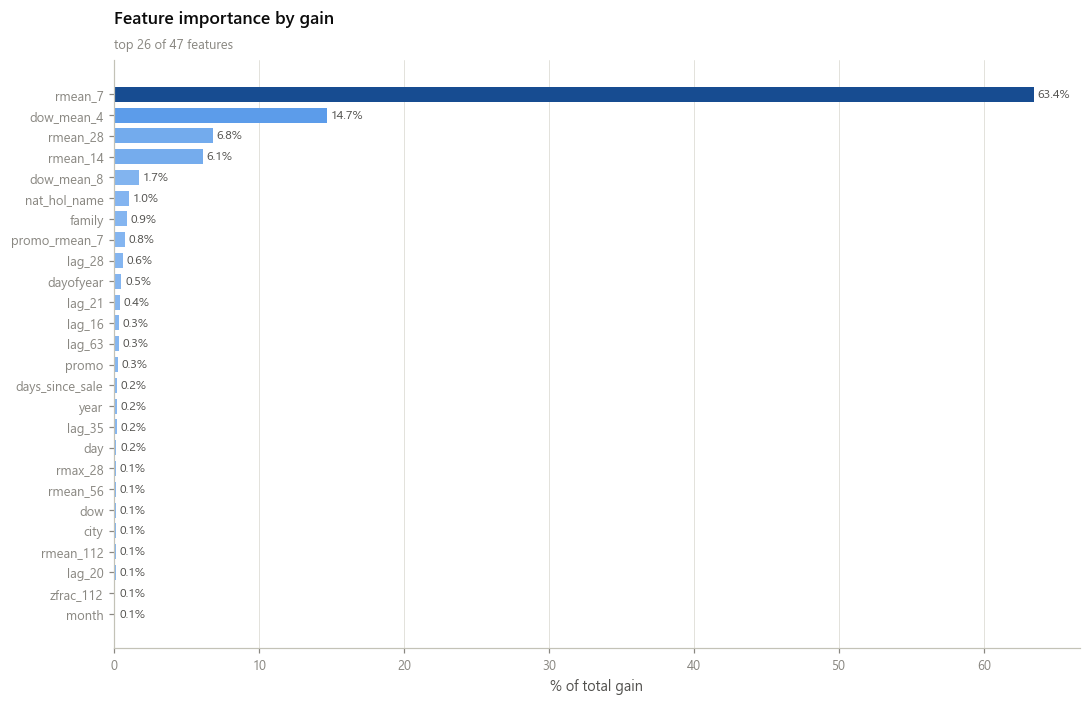

Gain by feature family:

recent level (lags & rolling means)    95.0 %
holidays                                1.1 %
calendar                                1.1 %
series identity                         1.1 %
promotions                              1.0 %
dormancy / zero structure               0.4 %
volatility                              0.3 %


In [16]:
imp = pd.DataFrame({"feature": model.feature_name(),
                    "gain": model.feature_importance("gain")})
imp["share"] = imp.gain / imp.gain.sum()
imp = imp.sort_values("gain", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6.5))
top = imp.head(26).iloc[::-1]
norm = (top.share - top.share.min()) / (top.share.max() - top.share.min())
ax.barh(top.feature, top.share * 100, color=SEQ(0.25 + 0.6 * norm.values), height=0.72)
for y, v in enumerate(top.share * 100):
    ax.text(v + 0.25, y, f"{v:.1f}%", va="center", fontsize=8, color=SECOND)
finish(ax, "Feature importance by gain", "top 26 of "
       f"{len(imp)} features", xlabel="% of total gain", ygrid=False, xgrid=True)
fig.tight_layout(); plt.show()

groups = {
    "recent level (lags & rolling means)": imp.feature.str.startswith(("lag_", "rmean_", "dow_mean")),
    "series identity": imp.feature.isin(["family", "store_nbr", "city", "state",
                                         "store_type", "cluster"]),
    "dormancy / zero structure": imp.feature.str.startswith(("zfrac", "days_since_sale")),
    "promotions": imp.feature.str.startswith("promo"),
    "calendar": imp.feature.isin(["dow", "day", "month", "year", "dayofyear", "is_weekend",
                                  "days_to_month_end", "payday_window"]),
    "holidays": imp.feature.str.contains("hol|nat|event", case=False, regex=True),
    "volatility": imp.feature.str.startswith(("rstd", "rmax")),
}
gs = pd.Series({k: imp.loc[m, "share"].sum() for k, m in groups.items()}).sort_values(ascending=False)
print("Gain by feature family:\n")
print((gs * 100).round(1).astype(str).add(" %").to_string())

---
## 8 · Where the error actually is

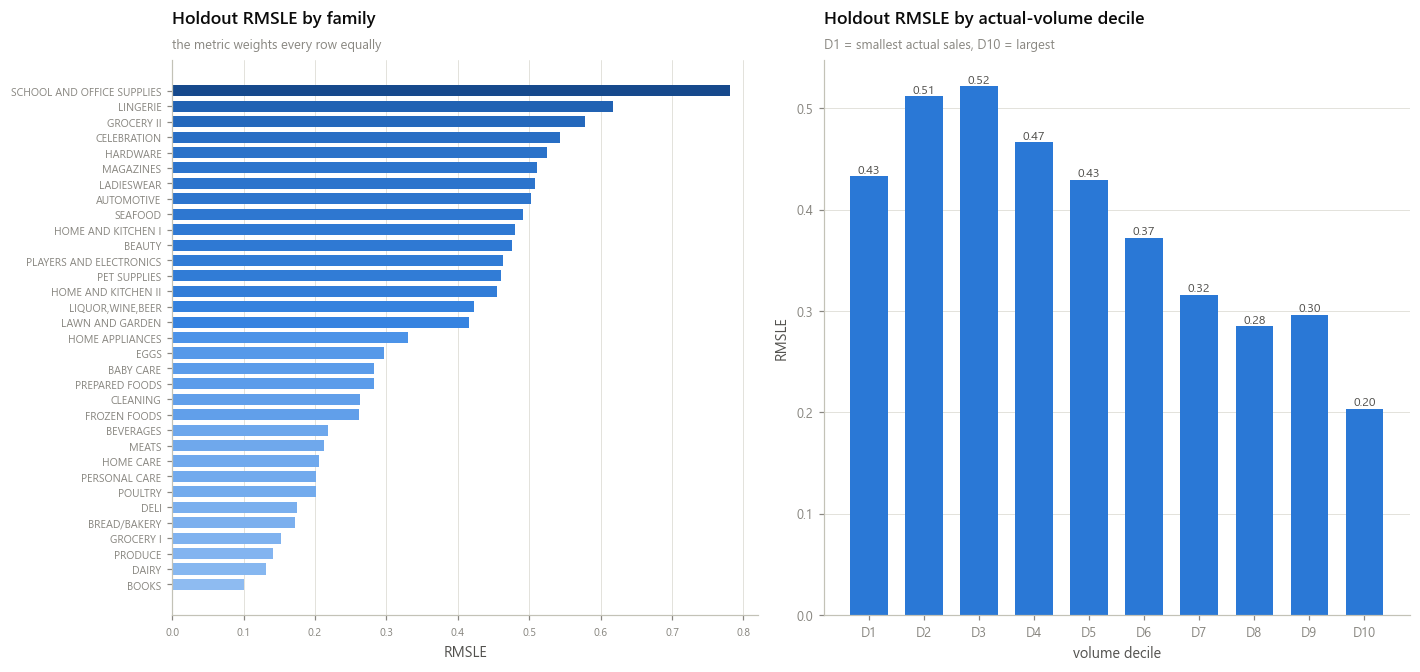

Worst 5 families:
                             rmsle  mean_units
family                                       
SCHOOL AND OFFICE SUPPLIES  0.782   59.948002
LINGERIE                    0.617    7.773000
GROCERY II                  0.578   28.971001
CELEBRATION                 0.543   12.463000
HARDWARE                    0.525    1.449000

Best 5 families:
               rmsle   mean_units
family                          
BREAD/BAKERY  0.172   540.273010
GROCERY I     0.152  4606.958984
PRODUCE       0.141  2288.750000
DAIRY         0.131   834.530029
BOOKS         0.100     0.010000

Share of total squared error from the bottom 3 volume deciles: 45.9%


In [17]:
va = D_clean.loc[va_m, ["date", "store_nbr", "family"]].copy()
va["actual"] = y_va
va["pred"] = p_val
va["sq"] = (np.log1p(va.pred) - np.log1p(va.actual)) ** 2

by_fam = (va.groupby("family", observed=True)
          .agg(rmsle=("sq", lambda s: np.sqrt(s.mean())), mean_units=("actual", "mean"))
          .sort_values("rmsle", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))

top = by_fam.iloc[::-1]
norm = (top.rmsle - top.rmsle.min()) / (top.rmsle.max() - top.rmsle.min())
axes[0].barh(top.index, top.rmsle, color=SEQ(0.22 + 0.65 * norm.values), height=0.72)
axes[0].tick_params(labelsize=7)
finish(axes[0], "Holdout RMSLE by family", "the metric weights every row equally",
       xlabel="RMSLE", ygrid=False, xgrid=True)

dec = va.assign(bucket=pd.qcut(va.actual.rank(method="first"), 10,
                               labels=[f"D{i}" for i in range(1, 11)]))
db = dec.groupby("bucket", observed=True).agg(rmsle=("sq", lambda s: np.sqrt(s.mean())),
                                              mean_units=("actual", "mean"))
axes[1].bar(db.index.astype(str), db.rmsle, color=CAT[0], width=0.68)
for i, (v, m) in enumerate(zip(db.rmsle, db.mean_units)):
    axes[1].text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8, color=SECOND)
finish(axes[1], "Holdout RMSLE by actual-volume decile",
       "D1 = smallest actual sales, D10 = largest", "volume decile", "RMSLE")

fig.tight_layout(); plt.show()

print("Worst 5 families:\n", by_fam.head(5).round(3).to_string())
print("\nBest 5 families:\n", by_fam.tail(5).round(3).to_string())
print(f"\nShare of total squared error from the bottom 3 volume deciles: "
      f"{dec[dec.bucket.isin(['D1','D2','D3'])].sq.sum() / dec.sq.sum():.1%}")

**Read.** The error is concentrated exactly where notebook 01 predicted it would be: in the
**low-volume rows**, not the big ones. `GROCERY I` forecasts well; the sparse, intermittent
families dominate the loss. This is RMSLE behaving as designed — a row selling 2 units counts
as much as one selling 2,000 — and it is where any further modelling effort belongs.

---
## 9 · Submission

Refit on **all** data through 2017-08-15, including the holdout, using the tree count that
early stopping selected. The earthquake quarantine is retained.

In [18]:
full_tr = (D_clean.date <= TRAIN_END) & D_clean.target.notna() & ~D_clean.date.isin(eq_dates)
print(f"refit rows: {full_tr.sum():,}  |  trees: {BEST_ROUNDS}")

final_model, _ = fit_predict(D_clean, full_tr, BEST_ROUNDS, label="refit on full history")

pred_test = np.clip(np.expm1(final_model.predict(D_clean.loc[te_m, FEATURES_FINAL])), 0, None)

sub_df = D_clean.loc[te_m, ["date", "store_nbr", "family"]].copy()
sub_df["sales"] = pred_test
sub_df["family"] = sub_df.family.astype(str)

key = test.assign(family=test.family.astype(str))[["id", "date", "store_nbr", "family"]]
submission = key.merge(sub_df, on=["date", "store_nbr", "family"], how="left")

assert len(submission) == len(test), "row count must match test.csv"
assert submission.sales.notna().all(), "every test row needs a prediction"
assert (submission.sales >= 0).all(), "RMSLE is undefined for negative predictions"
assert submission.id.equals(test.id), "ids must stay in test.csv order"

OUT = Path("../submissions") if Path("../data").exists() else Path("submissions")
OUT.mkdir(exist_ok=True)
submission[["id", "sales"]].to_csv(OUT / "submission_lgbm.csv", index=False)

print(f"\nwritten: {(OUT / 'submission_lgbm.csv').resolve()}")
print(submission[["id", "sales"]].head().to_string(index=False))
print(f"\npredicted sales — mean {submission.sales.mean():,.2f} | "
      f"median {submission.sales.median():,.2f} | max {submission.sales.max():,.0f} | "
      f"zeros {(submission.sales < 0.5).mean():.1%}")

refit rows: 1,694,682  |  trees: 867


  refit on full history               867 trees  152.4s



written: G:\Meu Drive\_Portifolio\Store Sales - Time Series Forecasting\submissions\submission_lgbm.csv
     id       sales
3000888    4.397532
3000889    0.006334
3000890    5.244267
3000891 2612.843220
3000892    0.089380

predicted sales — mean 443.63 | median 26.15 | max 14,296 | zeros 12.6%


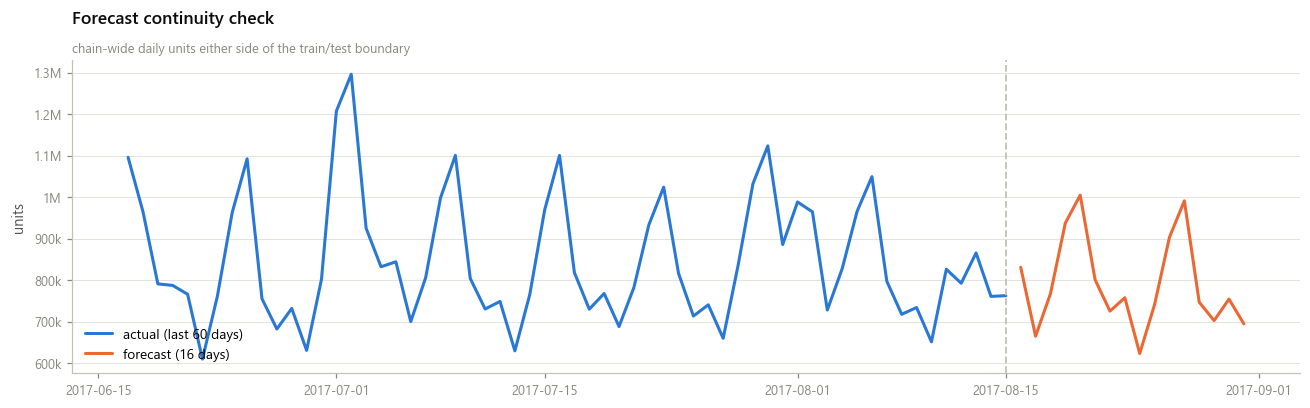

mean daily units, last 16 actual : 832,449
mean daily units, 16 forecast    : 790,543  (-5.0%)


In [19]:
# Sanity check: the forecast should look like a plausible continuation, not a level shift.
recent = train[train.date > TRAIN_END - pd.Timedelta(days=60)].groupby("date").sales.sum()
fut = submission.groupby("date").sales.sum()

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(recent.index, recent.values, color=CAT[0], label="actual (last 60 days)")
ax.plot(fut.index, fut.values, color=CAT[1], label="forecast (16 days)")
ax.axvline(TRAIN_END, color=BASELINE, lw=1.2, ls="--")
ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(ax, "Forecast continuity check",
       "chain-wide daily units either side of the train/test boundary", ylabel="units")
ax.legend(loc="lower left")
fig.tight_layout(); plt.show()

print(f"mean daily units, last 16 actual : {recent.tail(16).mean():,.0f}")
print(f"mean daily units, 16 forecast    : {fut.mean():,.0f}  "
      f"({fut.mean()/recent.tail(16).mean()-1:+.1%})")

Fundacion de Ambato, 2017-08-24 (Thursday) — stores [23, 50]
  rows affected in the submission : 66
  forecast units on the holiday   : 23,525
  forecast units, other Thursdays : 24,577
  implied model multiplier        : ×0.957

  notebook 01 §13 measured        : ×0.88, 95% CI ×0.63–×1.24 (n=4, not significant)


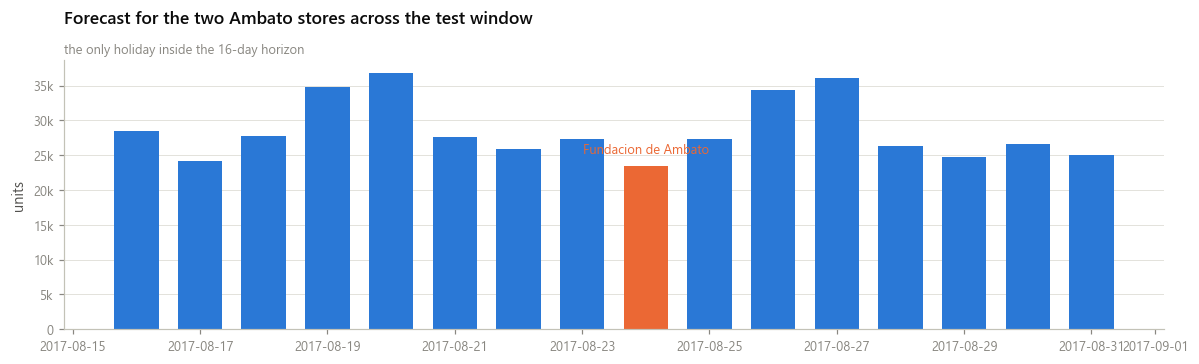

In [20]:
# The municipal holiday inside the forecast window — did the model actually respond to it?
amb_stores = sorted(stores.loc[stores.city == "Ambato", "store_nbr"])
AMB_DAY = pd.Timestamp("2017-08-24")
amb = submission[submission.store_nbr.isin(amb_stores)].copy()

per_day = amb.groupby("date").sales.sum()
same_dow = per_day[(per_day.index.dayofweek == AMB_DAY.dayofweek) & (per_day.index != AMB_DAY)]

print(f"Fundacion de Ambato, {AMB_DAY:%Y-%m-%d} ({AMB_DAY:%A}) — stores {amb_stores}")
print(f"  rows affected in the submission : {(amb.date == AMB_DAY).sum()}")
print(f"  forecast units on the holiday   : {per_day.loc[AMB_DAY]:,.0f}")
print(f"  forecast units, other Thursdays : {same_dow.mean():,.0f}")
print(f"  implied model multiplier        : ×{per_day.loc[AMB_DAY]/same_dow.mean():.3f}")
print(f"\n  notebook 01 §13 measured        : ×0.88, 95% CI ×0.63–×1.24 (n=4, not significant)")

fig, ax = plt.subplots(figsize=(11, 3.4))
cols = [CAT[1] if d == AMB_DAY else CAT[0] for d in per_day.index]
ax.bar(per_day.index, per_day.values, color=cols, width=0.7)
ax.annotate("Fundacion de Ambato", xy=(AMB_DAY, per_day.loc[AMB_DAY]), xytext=(0, 8),
            textcoords="offset points", ha="center", color=CAT[1], fontsize=8.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(ax, "Forecast for the two Ambato stores across the test window",
       "the only holiday inside the 16-day horizon", ylabel="units")
fig.tight_layout(); plt.show()

---
## 10 · Summary

**Result: holdout RMSLE 0.3966 against the naive baseline's 0.5206 — a 23.8% improvement**,
on an identical 16-day holdout. LightGBM on `log1p(sales)` with lag/rolling features at
horizons ≥ 16, named holiday categoricals, promotions and store metadata; no oil, no regional
flag, earthquake quarantined.

**What the model actually leans on.** Recent level — lags, rolling means, same-weekday
history — is **95% of total gain**. Everything else (holidays, calendar, series identity,
promotions, dormancy, volatility) splits the remaining 5%, roughly 1% each. That is worth
stating plainly, because it puts the two ablations in proportion: both were about
*correctness*, and neither was ever going to be the source of the score.

**On the earthquake.** Isolated at source rather than flagged, so no lag or rolling feature
anywhere in training sees the shock. Measured effect: **none** (0.40038 quarantined vs
0.40045 ignored). The dummy-only treatment was the worst of the three. Reported as measured,
not dressed up — the justification for keeping it is that the exposure was 135 days of rows
rather than 7, it is free, and the null result is specific to forecasting August 2017 from an
April 2016 shock.

**On holidays.** Named categoricals beat binary flags by **0.0047 on national-holiday rows**
(n=1,782) and lose by 0.0067 on local-holiday rows (n=66, too few to mean anything). The
ordinary-row control differs by 0.00013, so the comparison is clean. Globally the gain is
0.00016 — real, but small.

**Where the remaining error is.** The bottom three volume deciles carry **46% of all squared
error**. The worst family is `SCHOOL AND OFFICE SUPPLIES` (RMSLE 0.78) — which is not a
coincidence in an August window: the Ecuadorian Sierra school year starts in September, so
the test period sits on a back-to-school ramp that the model has only two prior Augusts to
learn from. `BOOKS` scores 0.10 simply because it is almost always zero and the model
correctly predicts zero.

That is where the next increment lives, and the obvious candidates are:

1. A **two-stage model** — classify "will it sell at all?", then predict magnitude given a
   sale. The 31% zero mass is currently handled implicitly by a regression that must
   straddle both regimes.
2. **Per-family or per-cluster models**, so sparse families are not fitted with parameters
   dominated by `GROCERY I`.
3. **Recursive or per-horizon models** — one model per day of the 16, letting near days use
   short lags that the current single direct model has to forgo.
4. **Tuning.** The hyper-parameters here are reasonable defaults, deliberately not searched,
   so the reported gain reflects the features rather than a tuning run.